In [ ]:
from google.colab import files
uploaded=files.upload()

Saving employee_salary_regression.csv to employee_salary_regression.csv


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('employee_salary_regression.csv')
df.head(2)

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        1000 non-null   object 
 1   age                1000 non-null   int64  
 2   years_experience   1000 non-null   int64  
 3   education_level    1000 non-null   object 
 4   job_role           1000 non-null   object 
 5   city_tier          1000 non-null   int64  
 6   performance_score  1000 non-null   float64
 7   num_skills         1000 non-null   int64  
 8   remote_work        1000 non-null   int64  
 9   annual_salary_usd  1000 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 78.3+ KB


In [ ]:
df.describe()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.668000,18.617000,2.046000,3.506200,7.161000,0.488000,137295.111970
std,11.536415,11.634848,0.826176,0.863775,3.103661,0.500106,34692.969621
min,22.000000,0.000000,1.000000,2.000000,2.000000,0.000000,66716.640000
25%,30.000000,8.000000,1.000000,2.800000,4.000000,0.000000,107616.092500
50%,41.000000,19.000000,2.000000,3.500000,7.000000,0.000000,137537.955000
75%,51.000000,29.000000,3.000000,4.300000,10.000000,1.000000,164807.105000
max,60.000000,40.000000,3.000000,5.000000,12.000000,1.000000,217067.540000


In [ ]:
df.columns

Index(['employee_id', 'age', 'years_experience', 'education_level', 'job_role',
       'city_tier', 'performance_score', 'num_skills', 'remote_work',
       'annual_salary_usd'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').columns

Index(['employee_id', 'education_level', 'job_role'], dtype='object')

In [ ]:
df.select_dtypes(include='number').columns

Index(['age', 'years_experience', 'city_tier', 'performance_score',
       'num_skills', 'remote_work', 'annual_salary_usd'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
employee_id,0
age,0
years_experience,0
education_level,0
job_role,0
city_tier,0
performance_score,0
num_skills,0
remote_work,0
annual_salary_usd,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in['education_level', 'job_role','city_tier']:
  print("_____________________")
  print(df[col].value_counts())
  print()

_____________________
education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64

_____________________
job_role
DevOps               190
Data Analyst         178
Product Manager      168
QA Engineer          165
Software Engineer    152
ML Engineer          147
Name: count, dtype: int64

_____________________
city_tier
3    365
1    319
2    316
Name: count, dtype: int64



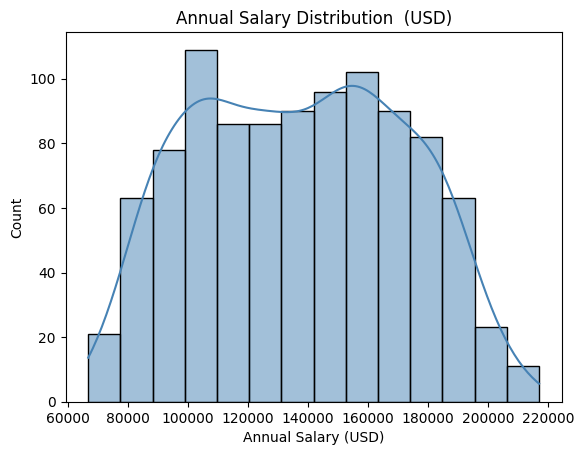

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['annual_salary_usd'], kde=True, color='steelblue')
plt.title('Annual Salary Distribution  (USD)')
plt.xlabel('Annual Salary (USD)')
plt.show()

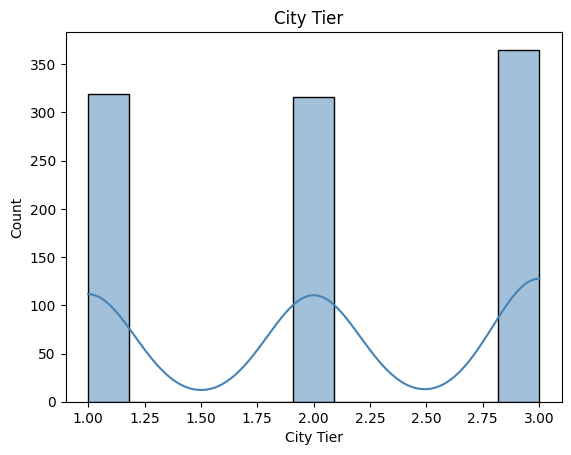

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['city_tier'], kde=True, color='steelblue')
plt.title('City Tier  ')
plt.xlabel('City Tier')
plt.show()

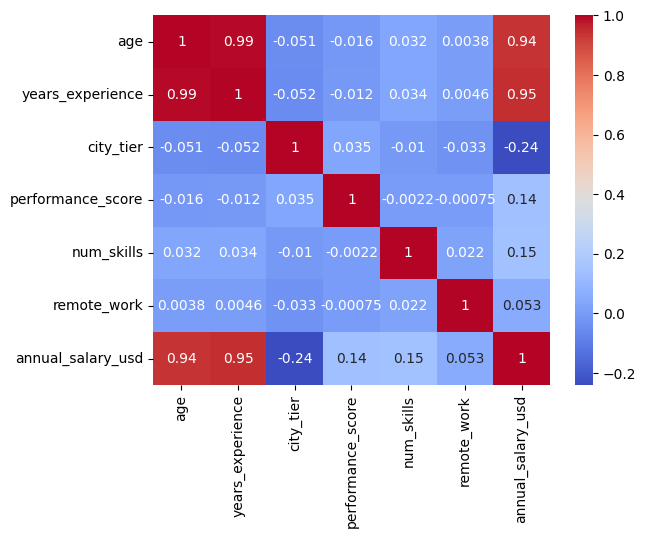

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
df_encoded = pd.get_dummies(
   df.drop(columns='employee_id'),
   columns=['education_level', 'job_role'],
   drop_first=True
)
df_encoded.head()

,age,years_experience,city_tier,performance_score,num_skills,remote_work,annual_salary_usd,education_level_High School,education_level_Master,education_level_PhD,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
0,29,9,1,2.4,3,0,106343.31,False,True,False,False,False,False,False,True
1,27,6,3,2.1,5,1,82852.60,False,False,False,False,True,False,False,False
2,36,13,1,4.1,7,1,142019.59,False,True,False,False,False,False,False,False
3,43,23,1,3.1,7,1,159972.80,True,False,False,True,False,False,False,False
4,24,1,1,3.7,12,1,94126.86,True,False,False,True,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
X=df_encoded.drop(columns=['annual_salary_usd'])
y=df_encoded['annual_salary_usd']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training set size:",X_train.shape)
print("Testing set size:",X_test.shape)

Training set size: (800, 14)
Testing set size: (200, 14)


In [ ]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

y_train_pred = lr_model.predict(x_train)
y_test_pred = lr_model.predict(x_test)

print("Model trained successfully")

Model trained successfully


In [ ]:
from sklearn.metrics import root_mean_squared_error

test_rmse = root_mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("RMSE:", round(test_rmse, 4))
print("R^2:", round(test_r2, 2))
print("MAE:", round(test_mae, 2))

RMSE: 4381.8704
R^2: 0.99
MAE: 3524.83


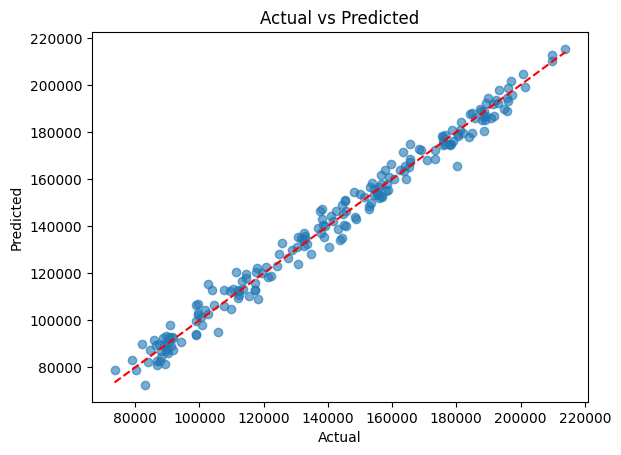

In [ ]:
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([(y_test.min()),(y_test.max())], [(y_test.min()), (y_test.max())], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import joblib
joblib.dump(lr_model, 'salary_model.pkl')

['salary_model.pkl']